# Static methods

PT and CAE

## imports and settings

Choose the patient counts and seed, and load the evidence and diagnosis descriptions.

In [2]:
from pathlib import Path
import pandas as pd
import torch
import ast

trainNo = 2000
validNo = 500
testNo = 500
rndseed = 42


project = Path(r"C:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis")
data = project / "data"
evidences = pd.read_json(data / "release_evidences.json",orient="index")

conditions = pd.read_json( data / "release_conditions.json", orient="index")

print("Evidence types:", len(evidences))
print("Diagnoses:", len(conditions))

Evidence types: 223
Diagnoses: 49


## load patient data

Read the training, validation, and test files and select the patients for this experiment. Use the same seed and patient counts when comparing methods.

In [3]:

columns = ["PATHOLOGY", "EVIDENCES", "INITIAL_EVIDENCE"]

train_df = pd.read_csv(
    data / "release_train_patients.zip",
    usecols=columns
)

validation_df = pd.read_csv(
    data / "release_validate_patients.zip",
    usecols=columns
)

test_df = pd.read_csv(
    data / "release_test_patients.zip",
    usecols=columns
)

train_df = train_df.sample(n=min(trainNo, len(train_df)), random_state=rndseed)
validation_df = validation_df.sample( n=min(validNo, len(validation_df)), random_state=rndseed)
test_df = test_df.sample( n=min(testNo, len(test_df)), random_state=rndseed)

print("Train:", len(train_df), "Validation:", len(validation_df), "Test:", len(test_df))
train_df.head(3)

Train: 2000 Validation: 500 Test: 500


,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
625083,Allergic sinusitis,"['E_86', 'E_87', 'E_124', 'E_169', 'E_181', 'E...",E_169
469074,Myasthenia gravis,"['E_28', 'E_38', 'E_52', 'E_63', 'E_65', 'E_17...",E_38
69338,Influenza,"['E_50', 'E_53', 'E_54_@_V_161', 'E_54_@_V_183...",E_129


### define feature columns
Create a column for each symptom or possible answer.
Use the same columns across the training, validation, and test splits.

In [4]:
feature_columns = []
default_answers = {}

for row, evidence in evidences.iterrows():
    evidence_name = evidence["name"]

    if evidence["data_type"] == "B":
        feature_columns.append(evidence_name)

    else:
        for answer in evidence["possible-values"]:
            feature_columns.append(f"{evidence_name}_@_{answer}")

        default_answers[evidence_name] =(f"{evidence_name}_@_{evidence['default_value']}")

print("Number of feature columns:", len(feature_columns))

Number of feature columns: 972


### encode patient evidence

Use 1 for recorded symptoms or answers and 0 for the others.
For unrecorded nonbinary evidence, use the dataset's default answer.

In [5]:
reformat = []

for frame in [train_df, validation_df, test_df]:
    features = pd.DataFrame(
        0,
        index=frame.index,
        columns=feature_columns,
        dtype="float32"
    )

    for index, row in frame.iterrows():
        patient_evidences = ast.literal_eval(row["EVIDENCES"])
        recorded_evidence = []

        for answer in patient_evidences:
            assert answer in features.columns, f"Unknown evidence: {answer}"

            features.at[index, answer] = 1

            evidence_name = answer.split("_@_", 1)[0]
            recorded_evidence.append(evidence_name)

        # Add default answers for unrecorded nonbinary evidence.
        for evidence_name, default_answer in default_answers.items():
            if evidence_name not in recorded_evidence:
                features.at[index, default_answer] = 1

    reformat.append(features)

train_features, validation_features, test_features = reformat

print("Training:", train_features.shape)
print("Validation:", validation_features.shape)
print("Test:", test_features.shape)

Training: (2000, 972)
Validation: (500, 972)
Test: (500, 972)


### encode diagnosis labels

Convert PATHOLOGY into one-hot encoding.

In [6]:
diagnoses = sorted(conditions["cond-name-eng"].unique())

reformat = []

for patient in [train_df, validation_df, test_df]:
    assert patient["PATHOLOGY"].isin(diagnoses).all(), "Unknown diagnosis found"

    labels = pd.get_dummies(patient["PATHOLOGY"])
    labels = labels.reindex(columns=diagnoses, fill_value=0)
    labels = labels.astype("float32")

    reformat.append(labels)

train_labels, validation_labels, test_labels = reformat

print("Training labels:", train_labels.shape)
print("Validation labels:", validation_labels.shape)
print("Test labels:", test_labels.shape)

Training labels: (2000, 49)
Validation labels: (500, 49)
Test labels: (500, 49)


## convert data to PyTorch tensors

Convert the encoded tables to the numeric arrays used by the models. Inputs contain evidence values; targets contain the known diagnoses.

In [7]:
train_inputs = torch.tensor(train_features.to_numpy(), dtype=torch.float32)
train_targets = torch.tensor(train_labels.to_numpy(), dtype=torch.float32)

validation_inputs = torch.tensor(validation_features.to_numpy(), dtype=torch.float32)
validation_targets = torch.tensor(validation_labels.to_numpy(), dtype=torch.float32)

test_inputs = torch.tensor(test_features.to_numpy(), dtype=torch.float32)
test_targets = torch.tensor(test_labels.to_numpy(), dtype=torch.float32)

print("Training:", train_inputs.shape, train_targets.shape)
print("Validation:", validation_inputs.shape, validation_targets.shape)
print("Test:", test_inputs.shape, test_targets.shape)

Training: torch.Size([2000, 972]) torch.Size([2000, 49])
Validation: torch.Size([500, 972]) torch.Size([500, 49])
Test: torch.Size([500, 972]) torch.Size([500, 49])


## prepare training batches

Pair each patient's evidence with their diagnosis and group patients into batches. Models can use these batches during training and evaluation; the tensors are also available for methods that use them directly.

In [8]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 128
reformat = []

for inputs, targets in [
    (train_inputs, train_targets),
    (validation_inputs, validation_targets),
    (test_inputs, test_targets)
]:
    patients = TensorDataset(inputs, targets)
    reformat.append(patients)

train_dataset, validation_dataset, test_dataset = reformat

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

validation_loader = DataLoader(validation_dataset, batch_size=batch_size)

test_loader = DataLoader(test_dataset,batch_size=batch_size)

## method implementation

Add the selected algorithm's setup, training or fitting, model saving, and evaluation here. Running this notebook currently prepares the data only.

## PT

PT ranks features by measuring how much prediction performance drops when their values are replaced. Every patient then receives features in the same order.

In [9]:
import sys
import time
import json
import numpy as np

sys.path.insert(0, str(project / "AFA_bench"))

from torch import nn
from torchrl.modules import MLP
from torchmetrics import AUROC
from tqdm import tqdm

from afabench.core.utils import set_seed
from afabench.components.initializers import ZeroInitializer
from afabench.components.unmaskers import DirectUnmasker
from afabench.components.methods.static.pt.models import BaseModel
from afabench.components.methods.static.pt.static_methods import StaticBaseMethod
from afabench.evaluation.eval import eval_afa_method

set_seed(rndseed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pt_epochs = 20
pt_max_features = 20

pt_output = project / "afabench" / "outputs" / "pt_run1"
pt_output.mkdir(parents=True, exist_ok=True)

counts = train_targets.sum(dim=0)
pt_weights = len(train_targets) / counts.clamp(min=1)
pt_weights = (pt_weights / pt_weights.sum()).to(device)

pt_validation_scores = []

def pt_validation_loss(predictions, labels):
    score = (predictions.argmax(dim=1) == labels).float().mean().item()
    pt_validation_scores.append(score)

    return nn.functional.cross_entropy(
        predictions, labels, weight=pt_weights
    )

def pt_progress(metrics):
    epoch = int(metrics["pt/epoch"])
    loss = metrics["pt/val_loss"]
    score = pt_validation_scores[-1]

    print(f"Epoch {epoch}: validation loss = {loss:.4f}, accuracy = {score:.2%}")

c:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis\AFA_bench\.venv\Lib\site-packages\torchrl\data\replay_buffers\samplers.py:36: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


### train the ranking model

Train a diagnosis model using all features. We use this model to measure feature importance; its accuracy is not the final 20-feature result.

In [10]:
pt_rank_predictor = MLP(
    in_features=train_inputs.shape[1],
    out_features=train_targets.shape[1],
    num_cells=[128, 128],
    activation_class=nn.ReLU
)

pt_rank_model = BaseModel(pt_rank_predictor).to(device)

start = time.perf_counter()

pt_rank_model.fit(
    train_loader,
    validation_loader,
    lr=0.001,
    nepochs=pt_epochs,
    loss_fn=nn.CrossEntropyLoss(weight=pt_weights),
    val_loss_fn=pt_validation_loss,
    val_loss_mode="min",
    verbose=False,
    metric_logger=pt_progress,
    metric_prefix="pt"
)

pt_rank_training_time = time.perf_counter() - start

Epoch 1: validation loss = 3.6629, accuracy = 60.40%
Epoch 2: validation loss = 3.0042, accuracy = 65.00%
Epoch 3: validation loss = 1.9141, accuracy = 86.20%
Epoch 4: validation loss = 0.9782, accuracy = 95.40%
Epoch 5: validation loss = 0.5061, accuracy = 97.20%
Epoch 6: validation loss = 0.3133, accuracy = 95.00%
Epoch 7: validation loss = 0.2120, accuracy = 96.60%
Epoch 8: validation loss = 0.1670, accuracy = 97.20%
Epoch 9: validation loss = 0.1291, accuracy = 97.40%
Epoch 10: validation loss = 0.1016, accuracy = 99.00%
Epoch 11: validation loss = 0.0986, accuracy = 98.60%
Epoch 12: validation loss = 0.0790, accuracy = 98.60%
Epoch 13: validation loss = 0.0700, accuracy = 99.00%
Epoch 14: validation loss = 0.0653, accuracy = 99.20%
Epoch 15: validation loss = 0.0722, accuracy = 98.60%
Epoch 16: validation loss = 0.0553, accuracy = 99.40%
Epoch 17: validation loss = 0.0502, accuracy = 99.00%
Epoch 18: validation loss = 0.0479, accuracy = 99.40%
Epoch 19: validation loss = 0.0449, a

### rank the features

Following AFABench's implementation, replace one validation feature at a time with values sampled from training patients.

Measure the drop in AUROC. Features causing larger drops receive higher rankings. Test patients are not used to choose the ranking.

In [11]:
pt_rank_model.eval()

rng = np.random.default_rng(rndseed)
pt_labels = validation_targets.argmax(dim=1)
pt_importance = np.zeros(train_inputs.shape[1])

start = time.perf_counter()

with torch.inference_mode():
    predictions = pt_rank_model(
        validation_inputs.to(device)
    ).softmax(dim=1).cpu()

    baseline = AUROC(
        task="multiclass",
        num_classes=train_targets.shape[1]
    )(predictions, pt_labels).item()

    for column in tqdm(range(train_inputs.shape[1]), desc="Ranking features"):
        features = validation_inputs.clone()

        rows = rng.choice(
            len(train_inputs),
            size=len(features),
            replace=True
        )
        features[:, column] = train_inputs[rows, column]

        predictions = pt_rank_model(
            features.to(device)
        ).softmax(dim=1).cpu()

        score = AUROC(
            task="multiclass",
            num_classes=train_targets.shape[1]
        )(predictions, pt_labels).item()

        pt_importance[column] = baseline - score

pt_ranking_time = time.perf_counter() - start
pt_ranked_features = np.argsort(pt_importance)[::-1]

pt_ranking = pd.DataFrame({
    "rank": range(1, len(feature_columns) + 1),
    "feature": [feature_columns[column] for column in pt_ranked_features],
    "importance": pt_importance[pt_ranked_features]
})

pt_ranking.to_csv(pt_output / "feature_ranking.csv", index=False)

display(pt_ranking.head(pt_max_features))

c:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis\AFA_bench\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
Ranking features: 100%|██████████| 972/972 [00:18<00:00, 53.59it/s]


,rank,feature,importance
0,1,E_13,0.000068
1,2,E_209,0.000036
2,3,E_14,0.000029
3,4,E_66,0.000024
4,5,E_55_@_V_166,0.000020
5,6,E_104,0.000020
6,7,E_55_@_V_55,0.000020
7,8,E_56_@_3,0.000020
8,9,E_54_@_V_198,0.000014
9,10,E_57_@_V_39,0.000014


### train the diagnosis models

Train a separate classifier for each feature budget, following AFABench's PT implementation.

The first model uses the highest-ranked feature, the second uses the top two, and so on until 20 features. Each model trains for up to 20 epochs.

In [12]:
pt_predictors = {}
pt_selected_history = {}

start = time.perf_counter()

for number in range(1, pt_max_features + 1):
    print(f"Training model with {number} features")

    columns = pt_ranked_features[:number].tolist()
    pt_selected_history[number] = columns

    train_subset = TensorDataset(
        train_inputs[:, columns], train_targets
    )
    validation_subset = TensorDataset(
        validation_inputs[:, columns], validation_targets
    )

    pt_train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    pt_validation_loader = DataLoader(
        validation_subset,
        batch_size=batch_size
    )

    predictor = MLP(
        in_features=number,
        out_features=train_targets.shape[1],
        num_cells=[128, 128],
        activation_class=nn.ReLU
    )

    trainer = BaseModel(predictor).to(device)

    trainer.fit(
        pt_train_loader,
        pt_validation_loader,
        lr=0.001,
        nepochs=pt_epochs,
        loss_fn=nn.CrossEntropyLoss(weight=pt_weights),
        val_loss_fn=pt_validation_loss,
        val_loss_mode="min",
        verbose=False,
        metric_logger=pt_progress,
        metric_prefix="pt"
    )

    predictor.eval()
    pt_predictors[number] = predictor

pt_predictor_training_time = time.perf_counter() - start

pt_model = StaticBaseMethod(
    selected_history=pt_selected_history,
    predictors=pt_predictors,
    device=device
)

pt_model.save(pt_output / "model")
torch.save(pt_rank_predictor.state_dict(), pt_output / "ranking_model.pt")

Training model with 1 features
Epoch 1: validation loss = 3.8815, accuracy = 0.20%
Epoch 2: validation loss = 3.8814, accuracy = 1.80%
Epoch 3: validation loss = 3.8777, accuracy = 1.40%
Epoch 4: validation loss = 3.8707, accuracy = 1.40%
Epoch 5: validation loss = 3.8728, accuracy = 1.40%
Epoch 6: validation loss = 3.8632, accuracy = 1.20%
Epoch 7: validation loss = 3.8527, accuracy = 1.40%
Epoch 8: validation loss = 3.8462, accuracy = 1.40%
Epoch 9: validation loss = 3.8466, accuracy = 4.80%
Epoch 10: validation loss = 3.8472, accuracy = 1.40%
Epoch 11: validation loss = 3.8413, accuracy = 2.40%
Epoch 12: validation loss = 3.8403, accuracy = 3.80%
Epoch 13: validation loss = 3.8434, accuracy = 1.40%
Epoch 14: validation loss = 3.8470, accuracy = 3.20%
Epoch 15: validation loss = 3.8441, accuracy = 3.00%
Epoch 16: validation loss = 3.8443, accuracy = 1.20%
Training model with 2 features
Epoch 1: validation loss = 3.8795, accuracy = 1.60%
Epoch 2: validation loss = 3.8500, accuracy = 4

### check validation and test accuracy

Evaluate PT using a budget of 20 encoded features. Every patient receives the same selected columns, while their recorded values differ.

In [13]:
pt_initializer = ZeroInitializer()
pt_unmasker = DirectUnmasker()

pt_results = []
pt_metrics = {}

for name, patients in [
    ("validation", validation_dataset),
    ("test", test_dataset)
]:
    patients.feature_shape = train_inputs.shape[1:]

    with torch.inference_mode():
        results = eval_afa_method(
            afa_action_fn=pt_model.act,
            afa_unmask_fn=pt_unmasker.unmask,
            n_selection_choices=train_inputs.shape[1],
            afa_initialize_fn=pt_initializer.initialize,
            dataset=patients,
            builtin_afa_predict_fn=pt_model.predict,
            device=device,
            selection_budget=pt_max_features,
            batch_size=batch_size
        )

    predictions = results[results["action_performed"] == 0]
    assert len(predictions) == len(patients)

    score = (
        predictions["builtin_predicted_class"] == predictions["true_class"]
    ).mean()

    pt_metrics[f"{name}_accuracy"] = float(score)
    pt_results.append(results)

    print(f"{name.capitalize()} accuracy: {score:.2%}")

pt_validation_results, pt_test_results = pt_results

100%|██████████| 4/4 [00:01<00:00,  2.83it/s]


Validation accuracy: 47.60%


100%|██████████| 4/4 [00:01<00:00,  3.16it/s]

Test accuracy: 46.20%


### save and preview results

Save the experiment settings, accuracy, and predictions. Show the first five test patients with their true and predicted diagnoses.

In [14]:
pt_settings = {
    "method": "PT",
    "seed": rndseed,
    "epochs_per_model": pt_epochs,
    "max_features": pt_max_features,
    "batch_size": batch_size,
    "hidden_units": [128, 128],
    "ranking_metric": "macro_auroc_drop",
    "train_patients": len(train_dataset),
    "validation_patients": len(validation_dataset),
    "test_patients": len(test_dataset),
    "feature_columns": feature_columns,
    "diagnoses": diagnoses,
    "default_answers": default_answers
}

with open(pt_output / "settings.json", "w", encoding="utf-8") as file:
    json.dump(pt_settings, file, indent=2)

pt_metrics["ranking_model_training_minutes"] = pt_rank_training_time / 60
pt_metrics["feature_ranking_minutes"] = pt_ranking_time / 60
pt_metrics["prefix_model_training_minutes"] = pt_predictor_training_time / 60

with open(pt_output / "metrics.json", "w", encoding="utf-8") as file:
    json.dump(pt_metrics, file, indent=2)

pt_test_predictions = pt_test_results[
    pt_test_results["action_performed"] == 0
]
pt_test_predictions.to_csv(pt_output / "test_predictions.csv", index=False)

diagnosis_names = dict(enumerate(diagnoses))

pt_predictions = pd.DataFrame()

pt_predictions["true_diagnosis"] = (
    pt_test_predictions["true_class"].map(diagnosis_names)
)
pt_predictions["predicted_diagnosis"] = (
    pt_test_predictions["builtin_predicted_class"].map(diagnosis_names)
)
pt_predictions["correct"] = (
    pt_predictions["true_diagnosis"] == pt_predictions["predicted_diagnosis"]
)

pt_predictions.to_json(
    pt_output / "test_results.json",
    orient="records",
    indent=2,
    force_ascii=False
)

display(pt_predictions.head(5))

,true_diagnosis,predicted_diagnosis,correct
2560,Bronchospasm / acute asthma exacerbation,Bronchospasm / acute asthma exacerbation,True
2561,Acute dystonic reactions,Bronchiolitis,False
2562,Chronic rhinosinusitis,Acute laryngitis,False
2563,HIV (initial infection),HIV (initial infection),True
2564,Panic attack,Pulmonary embolism,False


### plot PT accuracy

Show how diagnosis accuracy changes when using more of the ranked features.

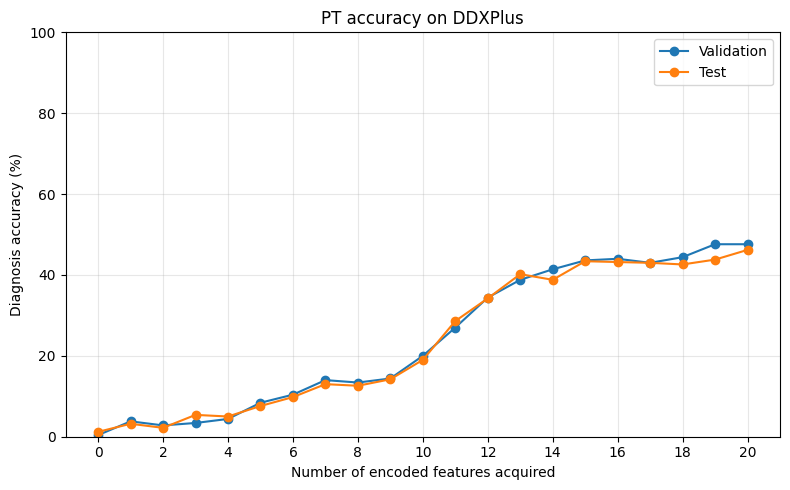

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for name, results in [
    ("Validation", pt_validation_results),
    ("Test", pt_test_results)
]:
    chart = results.copy()

    chart["features"] = chart["prev_selections_performed"].apply(len)
    chart["correct"] = (
        chart["builtin_predicted_class"] == chart["true_class"]
    )

    scores = chart.groupby("features")["correct"].mean() * 100

    plt.plot(scores.index, scores.values, marker="o", label=name)

plt.title("PT accuracy on DDXPlus")
plt.xlabel("Number of encoded features acquired")
plt.ylabel("Diagnosis accuracy (%)")
plt.xticks(range(0, pt_max_features + 1, 2))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(pt_output / "accuracy_by_features.png", dpi=300)
plt.show()

## CAE

CAE is a static method that learns a shared set of features for predicting diagnoses. Every patient receives the same features.

### set up CAE

Choose the training settings and output folder. Include a small helper to print validation accuracy during training.

In [17]:
import sys
import time
import json
import numpy as np

sys.path.insert(0, str(project / "AFA_bench"))

from torch import nn
from torchrl.modules import MLP

from afabench.core.utils import set_seed
from afabench.components.initializers import ZeroInitializer
from afabench.components.unmaskers import DirectUnmasker
from afabench.components.methods.static.common.models import BaseModel
from afabench.components.methods.static.common.static_methods import (
    ConcreteMask, DifferentiableSelector, StaticBaseMethod
)
from afabench.evaluation.eval import eval_afa_method

set_seed(rndseed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cae_epochs = 20
cae_selector_epochs = 2
cae_stages = 10
cae_max_features = 20

cae_output = project / "afabench" / "outputs" / "cae_run1"
cae_output.mkdir(parents=True, exist_ok=True)

counts = train_targets.sum(dim=0)
cae_weights = len(train_targets) / counts.clamp(min=1)
cae_weights = (cae_weights / cae_weights.sum()).to(device)


class CAEValidationLoss(nn.CrossEntropyLoss):
    def forward(self, predictions, labels):
        self.accuracy = (
            predictions.argmax(dim=1) == labels
        ).float().mean().item()

        return super().forward(predictions, labels)


cae_validation_loss = CAEValidationLoss(weight=cae_weights)


def cae_progress(metrics):
    epoch = int(metrics["cae/epoch"])
    score = cae_validation_loss.accuracy

    if "cae/temperature" in metrics:
        temp = metrics["cae/temperature"]

        print(
            f"Epoch {epoch}: temp = {temp:.4f}, "
            f"hard-mask validation accuracy = {score:.2%}"
        )
    else:
        loss = metrics["cae/val_loss"]

        print(
            f"Epoch {epoch}: validation loss = {loss:.4f}, "
            f"accuracy = {score:.2%}"
        )

### train the feature selector

Train the selector and a diagnosis model together so the selector learns useful features.

Temperature controls how definite the feature choices are. We gradually reduce it over 10 stages, with 2 epochs per stage: 20 epochs total.

The accuracy printed here uses sampled feature choices. We evaluate the final fixed feature set later.

In [18]:
cae_predictor = MLP(
    in_features=train_inputs.shape[1],
    out_features=train_targets.shape[1],
    num_cells=[128, 128],
    activation_class=nn.ReLU
)

cae_mask = ConcreteMask(
    num_features=train_inputs.shape[1],
    num_select=cae_max_features
)

cae_selector = DifferentiableSelector(
    model=cae_predictor,
    selector_layer=cae_mask
).to(device)

start = time.perf_counter()

cae_selector.fit(
    train_loader,
    validation_loader,
    lr=0.001,
    nepochs=cae_selector_epochs,
    temp_steps=cae_stages,
    start_temp=10.0,
    end_temp=0.01,
    patience=5,
    loss_fn=nn.CrossEntropyLoss(weight=cae_weights),
    val_loss_fn=cae_validation_loss,
    val_loss_mode="min",
    verbose=False,
    metric_logger=cae_progress,
    metric_prefix="cae"
)

cae_selector_training_time = time.perf_counter() - start
cae_selector.eval()

torch.save(
    cae_selector.state_dict(),
    cae_output / "selector_state.pt"
)

Epoch 1: temp = 10.0000, hard-mask validation accuracy = 2.80%
Epoch 2: temp = 10.0000, hard-mask validation accuracy = 2.80%
Epoch 3: temp = 4.6416, hard-mask validation accuracy = 3.60%
Epoch 4: temp = 4.6416, hard-mask validation accuracy = 3.20%
Epoch 5: temp = 2.1544, hard-mask validation accuracy = 6.80%
Epoch 6: temp = 2.1544, hard-mask validation accuracy = 10.20%
Epoch 7: temp = 1.0000, hard-mask validation accuracy = 11.40%
Epoch 8: temp = 1.0000, hard-mask validation accuracy = 10.40%
Epoch 9: temp = 0.4642, hard-mask validation accuracy = 13.80%
Epoch 10: temp = 0.4642, hard-mask validation accuracy = 13.40%
Epoch 11: temp = 0.2154, hard-mask validation accuracy = 11.00%
Epoch 12: temp = 0.2154, hard-mask validation accuracy = 13.20%
Epoch 13: temp = 0.1000, hard-mask validation accuracy = 13.40%
Epoch 14: temp = 0.1000, hard-mask validation accuracy = 13.40%
Epoch 15: temp = 0.0464, hard-mask validation accuracy = 15.40%
Epoch 16: temp = 0.0464, hard-mask validation accura

### get the selected features

Convert the learned choices into a fixed feature set.

Following AFABench's code, remove duplicate choices and fill any shortage with the first unused columns. Sort the final set by column index.

This order is not an importance ranking.

In [19]:
cae_features = cae_mask.logits.detach().cpu().numpy().argmax(axis=1)
cae_features = np.unique(cae_features)

cae_extra_count = cae_max_features - len(cae_features)

cae_remaining = np.setdiff1d(
    np.arange(train_inputs.shape[1]), cae_features
)
cae_added_features = cae_remaining[:cae_extra_count]

cae_features = np.sort(
    np.concatenate([cae_features, cae_added_features])
)

print("Extra columns added to fill the budget:", cae_extra_count)

cae_selected = pd.DataFrame({
    "order": range(1, cae_max_features + 1),
    "feature": [feature_columns[column] for column in cae_features],
    "added_to_fill_budget": [
        column in cae_added_features for column in cae_features
    ]
})

cae_selected.to_csv(
    cae_output / "selected_features.csv",
    index=False
)

display(cae_selected)

Extra columns added to fill the budget: 0


,order,feature,added_to_fill_budget
0,1,E_55_@_V_20,False
1,2,E_55_@_V_175,False
2,3,E_55_@_V_188,False
3,4,E_57_@_V_171,False
4,5,E_57_@_V_189,False
5,6,E_54_@_V_154,False
6,7,E_54_@_V_184,False
7,8,E_133_@_V_40,False
8,9,E_133_@_V_89,False
9,10,E_133_@_V_125,False


### train the diagnosis models

Following AFABench's implementation, train a separate diagnosis model for each budget from 1 to 20 features.

Each model uses the first columns from the selected set and trains for up to 20 epochs. The selector is not retrained for each budget.

In [20]:
cae_predictors = {}
cae_selected_history = {}

start = time.perf_counter()

for number in range(1, cae_max_features + 1):
    print(f"Training model with {number} features")

    columns = cae_features[:number].tolist()
    cae_selected_history[number] = columns

    train_subset = TensorDataset(
        train_inputs[:, columns], train_targets
    )
    validation_subset = TensorDataset(
        validation_inputs[:, columns], validation_targets
    )

    cae_train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    cae_validation_loader = DataLoader(
        validation_subset,
        batch_size=batch_size
    )

    predictor = MLP(
        in_features=number,
        out_features=train_targets.shape[1],
        num_cells=[128, 128],
        activation_class=nn.ReLU
    )

    trainer = BaseModel(predictor).to(device)

    trainer.fit(
        cae_train_loader,
        cae_validation_loader,
        lr=0.001,
        nepochs=cae_epochs,
        loss_fn=nn.CrossEntropyLoss(weight=cae_weights),
        val_loss_fn=cae_validation_loss,
        val_loss_mode="min",
        verbose=False,
        metric_logger=cae_progress,
        metric_prefix="cae"
    )

    predictor.eval()
    cae_predictors[number] = predictor

cae_predictor_training_time = time.perf_counter() - start

cae_model = StaticBaseMethod(
    selected_history=cae_selected_history,
    predictors=cae_predictors,
    device=device
)

cae_model.save(cae_output / "model")

Training model with 1 features
Epoch 1: validation loss = 3.8506, accuracy = 5.20%
Epoch 2: validation loss = 3.8067, accuracy = 5.40%
Epoch 3: validation loss = 3.7598, accuracy = 4.20%
Epoch 4: validation loss = 3.7255, accuracy = 4.20%
Epoch 5: validation loss = 3.7223, accuracy = 3.80%
Epoch 6: validation loss = 3.7154, accuracy = 4.00%
Epoch 7: validation loss = 3.7145, accuracy = 4.00%
Epoch 8: validation loss = 3.7094, accuracy = 5.40%
Epoch 9: validation loss = 3.7093, accuracy = 2.20%
Epoch 10: validation loss = 3.7107, accuracy = 2.20%
Epoch 11: validation loss = 3.7063, accuracy = 3.60%
Epoch 12: validation loss = 3.7118, accuracy = 3.60%
Epoch 13: validation loss = 3.7118, accuracy = 5.40%
Epoch 14: validation loss = 3.7084, accuracy = 3.80%
Epoch 15: validation loss = 3.7075, accuracy = 3.80%
Training model with 2 features
Epoch 1: validation loss = 3.8763, accuracy = 2.80%
Epoch 2: validation loss = 3.8495, accuracy = 2.80%
Epoch 3: validation loss = 3.8077, accuracy = 2.

### check validation and test accuracy

Evaluate CAE with a budget of 20 encoded features. Every patient receives the same columns, while the values depend on their recorded evidence.

In [21]:
cae_initializer = ZeroInitializer()
cae_unmasker = DirectUnmasker()

cae_results = []
cae_metrics = {}

for name, patients in [
    ("validation", validation_dataset),
    ("test", test_dataset)
]:
    patients.feature_shape = train_inputs.shape[1:]

    with torch.inference_mode():
        results = eval_afa_method(
            afa_action_fn=cae_model.act,
            afa_unmask_fn=cae_unmasker.unmask,
            n_selection_choices=train_inputs.shape[1],
            afa_initialize_fn=cae_initializer.initialize,
            dataset=patients,
            builtin_afa_predict_fn=cae_model.predict,
            device=device,
            selection_budget=cae_max_features,
            batch_size=batch_size
        )

    predictions = results[results["action_performed"] == 0]
    assert len(predictions) == len(patients)

    score = (
        predictions["builtin_predicted_class"] == predictions["true_class"]
    ).mean()

    cae_metrics[f"{name}_accuracy"] = float(score)
    cae_results.append(results)

    print(f"{name.capitalize()} accuracy: {score:.2%}")

cae_validation_results, cae_test_results = cae_results

100%|██████████| 4/4 [00:00<00:00,  4.35it/s]


Validation accuracy: 16.20%


100%|██████████| 4/4 [00:00<00:00,  4.19it/s]

Test accuracy: 14.40%


### save and preview results

Save the settings, training times, accuracy, and predictions. Show the first five test patients with their true and predicted diagnoses.

In [22]:
cae_settings = {
    "method": "CAE",
    "seed": rndseed,
    "epochs_per_classifier": cae_epochs,
    "selector_epochs_per_stage": cae_selector_epochs,
    "selector_stages": cae_stages,
    "start_temp": 10.0,
    "end_temp": 0.01,
    "max_features": cae_max_features,
    "batch_size": batch_size,
    "hidden_units": [128, 128],
    "feature_order": "column_index",
    "added_feature_columns": cae_added_features.tolist(),
    "train_patients": len(train_dataset),
    "validation_patients": len(validation_dataset),
    "test_patients": len(test_dataset),
    "feature_columns": feature_columns,
    "diagnoses": diagnoses,
    "default_answers": default_answers
}

with open(cae_output / "settings.json", "w", encoding="utf-8") as file:
    json.dump(cae_settings, file, indent=2)

cae_metrics["selector_training_minutes"] = cae_selector_training_time / 60
cae_metrics["prefix_model_training_minutes"] = cae_predictor_training_time / 60

with open(cae_output / "metrics.json", "w", encoding="utf-8") as file:
    json.dump(cae_metrics, file, indent=2)

cae_test_predictions = cae_test_results[
    cae_test_results["action_performed"] == 0
]
cae_test_predictions.to_csv(
    cae_output / "test_predictions.csv",
    index=False
)

diagnosis_names = dict(enumerate(diagnoses))
cae_predictions = pd.DataFrame()

cae_predictions["true_diagnosis"] = (
    cae_test_predictions["true_class"].map(diagnosis_names)
)
cae_predictions["predicted_diagnosis"] = (
    cae_test_predictions["builtin_predicted_class"].map(diagnosis_names)
)
cae_predictions["correct"] = (
    cae_predictions["true_diagnosis"] == cae_predictions["predicted_diagnosis"]
)

cae_predictions.to_json(
    cae_output / "test_results.json",
    orient="records",
    indent=2,
    force_ascii=False
)

display(cae_predictions.head(5))

,true_diagnosis,predicted_diagnosis,correct
2560,Bronchospasm / acute asthma exacerbation,Bronchospasm / acute asthma exacerbation,True
2561,Acute dystonic reactions,Pulmonary neoplasm,False
2562,Chronic rhinosinusitis,Pulmonary neoplasm,False
2563,HIV (initial infection),Chagas,False
2564,Panic attack,Pulmonary neoplasm,False


### plot CAE accuracy

Show how diagnosis accuracy changes as more columns from the selected set become available.

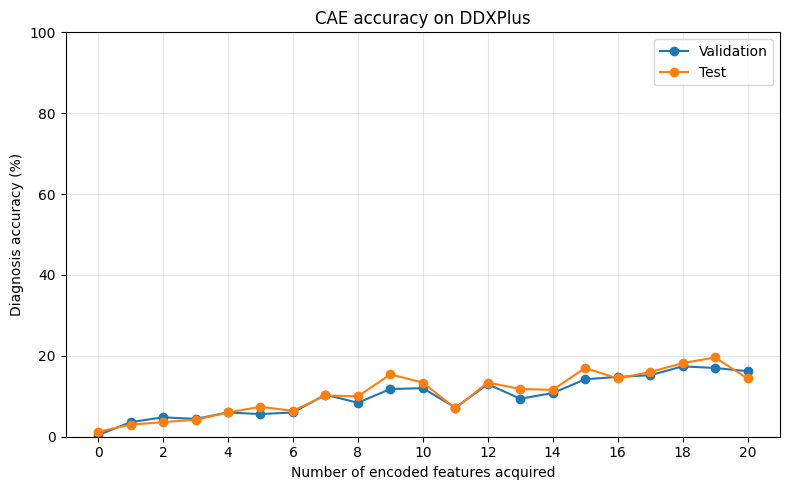

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for name, results in [
    ("Validation", cae_validation_results),
    ("Test", cae_test_results)
]:
    chart = results.copy()

    chart["features"] = chart["prev_selections_performed"].apply(len)
    chart["correct"] = (
        chart["builtin_predicted_class"] == chart["true_class"]
    )

    scores = chart.groupby("features")["correct"].mean() * 100

    plt.plot(scores.index, scores.values, marker="o", label=name)

plt.title("CAE accuracy on DDXPlus")
plt.xlabel("Number of encoded features acquired")
plt.ylabel("Diagnosis accuracy (%)")
plt.xticks(range(0, cae_max_features + 1, 2))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(cae_output / "accuracy_by_features.png", dpi=300)
plt.show()